# DMR Visualization

Contour-based DEM.
2D map, hillshade, 3D.

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from scipy.interpolate import griddata
from shapely.geometry import shape
from pyproj import Transformer
from pathlib import Path
import json

print("knihovny nacteny")

knihovny nacteny


## 1. Bounding Box

In [2]:
# nacteni geojson a transformace do s-jtsk
geojson_candidates = [
    Path("data.geojson"), Path("../data.geojson"),
    Path("data_A1.geojson"), Path("../data_A1.geojson"),
    Path("data_A2.geojson"), Path("../data_A2.geojson"),
    Path("data_A3.geojson"), Path("../data_A3.geojson"),
    Path("data_A4.geojson"), Path("../data_A4.geojson"),
    Path("data_B.geojson"), Path("../data_B.geojson"),
]
geojson_path = next((p for p in geojson_candidates if p.exists()), None)
if geojson_path is None:
    raise FileNotFoundError("nenalezen data.geojson ani data_A*.geojson/data_B.geojson v aktualni ani nadrazene slozce")
print(f"pouzity geojson: {geojson_path}")
with open(geojson_path, "r", encoding="utf-8") as f:
    gj = json.load(f)

geom_wgs = shape(gj["features"][0]["geometry"])
minx_wgs, miny_wgs, maxx_wgs, maxy_wgs = geom_wgs.bounds
print(f"bbox wgs84: {minx_wgs:.4f}, {miny_wgs:.4f}, {maxx_wgs:.4f}, {maxy_wgs:.4f}")

# transformace do epsg:5514 (s-jtsk)
transformer = Transformer.from_crs(4326, 5514, always_xy=True)
xmin, ymin = transformer.transform(minx_wgs, miny_wgs)
xmax, ymax = transformer.transform(maxx_wgs, maxy_wgs)
bbox_sjtsk = (xmin, ymin, xmax, ymax)
print(f"bbox s-jtsk: {xmin:.0f}, {ymin:.0f}, {xmax:.0f}, {ymax:.0f}")

pouzity geojson: ..\data_A1.geojson
bbox wgs84: 18.0012, 49.1338, 18.1386, 49.2236
bbox s-jtsk: -497733, -1177527, -486868, -1168462


## 2. Contours

In [3]:
import unicodedata
import pandas as pd

CONTOUR_PATH = Path("../data/raw/vrstevnice.gpkg")

# nacteni vrstevnic v bounding boxu
contours = gpd.read_file(CONTOUR_PATH, bbox=bbox_sjtsk)
if contours.crs and contours.crs.to_epsg() != 5514:
    contours = contours.to_crs(5514)

# autodetekce sloupce s vyskou (normalizace diakritiky)
def _norm(text):
    return unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("ascii").lower()

height_col = None
for col in contours.columns:
    norm = _norm(col)
    if "vyska" in norm or "elev" in norm or "height" in norm:
        height_col = col
        break

if height_col is None:
    raise ValueError(f"nenalezen sloupec s vyskou. sloupce: {list(contours.columns)}")

contours["elev"] = pd.to_numeric(contours[height_col], errors="coerce")
contours = contours.dropna(subset=["elev"])
print(f"nacteno {len(contours):,} vrstevnic, vyska: {height_col}")
print(f"rozsah vysek: {contours.elev.min():.0f} - {contours.elev.max():.0f} m n. m.")

nacteno 3,641 vrstevnic, vyska: VYSKA
rozsah vysek: 375 - 815 m n. m.


## 3. DEM Interpolation

In [4]:
# extrakce bodu z vrstevnic (sample kazdych 50 m podel linie)
SAMPLE_DIST = 50  # metru
pts_x, pts_y, pts_z = [], [], []

for _, row in contours.iterrows():
    geom = row.geometry
    elev = row.elev
    if geom.geom_type == "MultiLineString":
        lines = list(geom.geoms)
    else:
        lines = [geom]
    for line in lines:
        length = line.length
        n_samples = max(2, int(length / SAMPLE_DIST))
        for i in range(n_samples + 1):
            pt = line.interpolate(i / n_samples, normalized=True)
            pts_x.append(pt.x)
            pts_y.append(pt.y)
            pts_z.append(elev)

pts_x = np.array(pts_x)
pts_y = np.array(pts_y)
pts_z = np.array(pts_z)
print(f"extrahovano {len(pts_x):,} vyskovych bodu z vrstevnic")

# orizneme interpolacni grid na rozsah dat (+ maly buffer)
BUFFER = 200  # metru
cx_min, cx_max = pts_x.min() - BUFFER, pts_x.max() + BUFFER
cy_min, cy_max = pts_y.min() - BUFFER, pts_y.max() + BUFFER
gx_min = max(xmin, cx_min)
gx_max = min(xmax, cx_max)
gy_min = max(ymin, cy_min)
gy_max = min(ymax, cy_max)

# interpolace do pravidelne mrizky
RESOLUTION = 50  # metru
grid_x = np.arange(gx_min, gx_max, RESOLUTION)
grid_y = np.arange(gy_min, gy_max, RESOLUTION)
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)

print(f"interpoluji do mrizky {grid_xx.shape[1]} x {grid_xx.shape[0]} ({RESOLUTION} m)...")
dem = griddata(
    (pts_x, pts_y), pts_z,
    (grid_xx, grid_yy),
    method="linear",
    fill_value=np.nan,
)

# --- orez konkavnim obalem dat (orizne hranicni artefakty) ---
from shapely import MultiPoint, concave_hull, contains_xy

# subsample bodu pro vypocet obalu (rychlost)
step = max(1, len(pts_x) // 30000)
mp = MultiPoint(list(zip(pts_x[::step], pts_y[::step])))
data_hull = concave_hull(mp, ratio=0.05)  # tesny obal kolem dat
data_hull_buf = data_hull.buffer(100)     # jen mirny buffer 100 m

# maskuj bunky mimo konkavni obal dat
in_hull = contains_xy(data_hull_buf, grid_xx.ravel(), grid_yy.ravel())
outside_hull = ~in_hull.reshape(grid_xx.shape)
n_outside = (~np.isnan(dem) & outside_hull).sum()
dem[outside_hull] = np.nan
print(f"konkavni obal (ratio=0.05): orezano {n_outside:,} bunek mimo datovy obal")

# maskovani oblasti prilis daleko od dat (max 500 m od nejblizsiho bodu)
from scipy.spatial import cKDTree
MAX_FILL_DIST = 300  # metru - dal od dat nechat NaN
pts_tree = cKDTree(np.column_stack([pts_x, pts_y]))
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
dists_to_nearest, _ = pts_tree.query(grid_pts, k=1)
dist_grid = dists_to_nearest.reshape(grid_xx.shape)

# vyplneni blizkych NaN oblasti nearest-neighbor, vzdalene nechat NaN
mask_nan = np.isnan(dem)
mask_fillable = mask_nan & (dist_grid <= MAX_FILL_DIST)
if mask_fillable.any():
    dem_nn = griddata((pts_x, pts_y), pts_z, (grid_xx, grid_yy), method="nearest")
    dem[mask_fillable] = dem_nn[mask_fillable]
    print(f"vyplneno {mask_fillable.sum():,} blizkych NaN bunek, ponechano {(mask_nan & ~mask_fillable).sum():,} NaN (bez dat)")

# orez na realny rozsah vysek
z_min, z_max = pts_z.min(), pts_z.max()
dem = np.clip(dem, z_min, z_max)

# aktualizace extent pro vizualizace
extent = [gx_min, gx_max, gy_min, gy_max]
valid = ~np.isnan(dem)
print(f"dmr: {dem.shape}, vysky {np.nanmin(dem):.0f} - {np.nanmax(dem):.0f} m n. m.")
print(f"pokryti: {valid.sum():,}/{dem.size:,} bunek ({100*valid.sum()/dem.size:.1f}%)")

extrahovano 126,114 vyskovych bodu z vrstevnic
interpoluji do mrizky 218 x 182 (50 m)...
konkavni obal (ratio=0.05): orezano 928 bunek mimo datovy obal
vyplneno 606 blizkych NaN bunek, ponechano 1,937 NaN (bez dat)
dmr: (182, 218), vysky 375 - 815 m n. m.
pokryti: 37,739/39,676 bunek (95.1%)


## 4. 2D Elevation Map

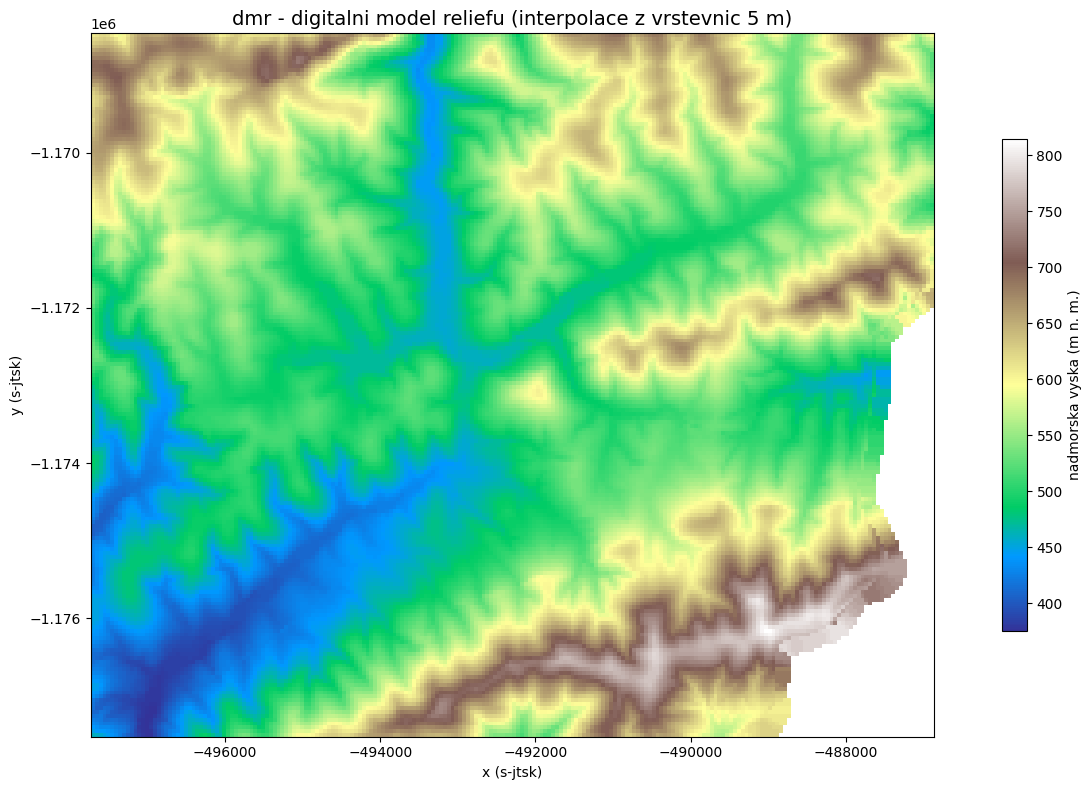

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))
extent = [xmin, xmax, ymin, ymax]
im = ax.imshow(
    dem, origin="lower", extent=extent,
    cmap="terrain", vmin=np.nanmin(dem), vmax=np.nanmax(dem),
)
cbar = plt.colorbar(im, ax=ax, shrink=0.7, label="nadmorska vyska (m n. m.)")
ax.set_title("dmr - digitalni model reliefu (interpolace z vrstevnic 5 m)", fontsize=14)
ax.set_xlabel("x (s-jtsk)")
ax.set_ylabel("y (s-jtsk)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 5. Hillshade

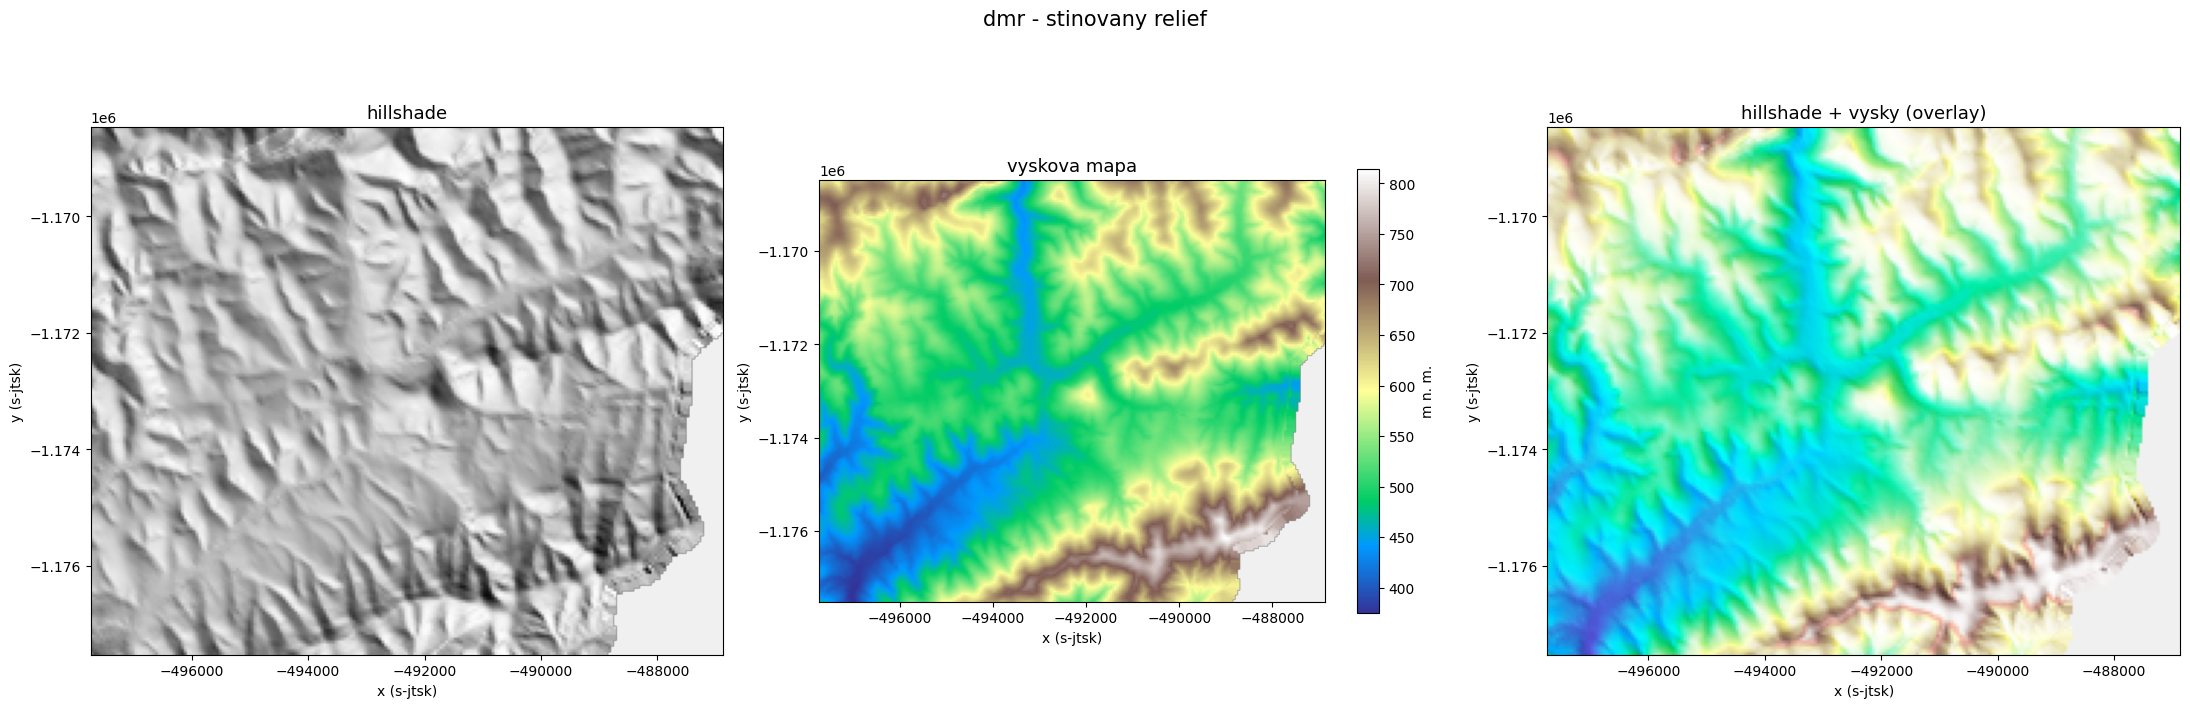

In [6]:
# hillshade pomoci matplotlib lightsource
ls = LightSource(azdeg=315, altdeg=45)

# docasne vyplnime NaN pro vypocet hillshade
dem_filled = dem.copy()
nan_mask = np.isnan(dem_filled)
if nan_mask.any():
    dem_nn_fill = griddata((pts_x, pts_y), pts_z, (grid_xx, grid_yy), method="nearest")
    dem_filled[nan_mask] = dem_nn_fill[nan_mask]

hillshade = ls.hillshade(dem_filled, vert_exag=2, dx=RESOLUTION, dy=RESOLUTION)
hillshade[nan_mask] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1) cisty hillshade
axes[0].imshow(np.ma.masked_invalid(hillshade), origin="lower", extent=extent, cmap="gray")
axes[0].set_title("hillshade", fontsize=13)
axes[0].set_aspect("equal")

# 2) vyskova mapa
im1 = axes[1].imshow(np.ma.masked_invalid(dem), origin="lower", extent=extent, cmap="terrain")
plt.colorbar(im1, ax=axes[1], shrink=0.7, label="m n. m.")
axes[1].set_title("vyskova mapa", fontsize=13)
axes[1].set_aspect("equal")

# 3) kombinace: hillshade + vysky
rgb = ls.shade(dem_filled, cmap=plt.cm.terrain, vert_exag=2, blend_mode="overlay",
               dx=RESOLUTION, dy=RESOLUTION)
# zamaskovat oblasti bez dat (nastavit alpha=0)
rgb[nan_mask, 3] = 0.0
axes[2].imshow(rgb, origin="lower", extent=extent)
axes[2].set_title("hillshade + vysky (overlay)", fontsize=13)
axes[2].set_aspect("equal")

for ax in axes:
    ax.set_xlabel("x (s-jtsk)")
    ax.set_ylabel("y (s-jtsk)")
    ax.set_facecolor("#f0f0f0")

plt.suptitle("dmr - stinovany relief", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 6. 3D Terrain

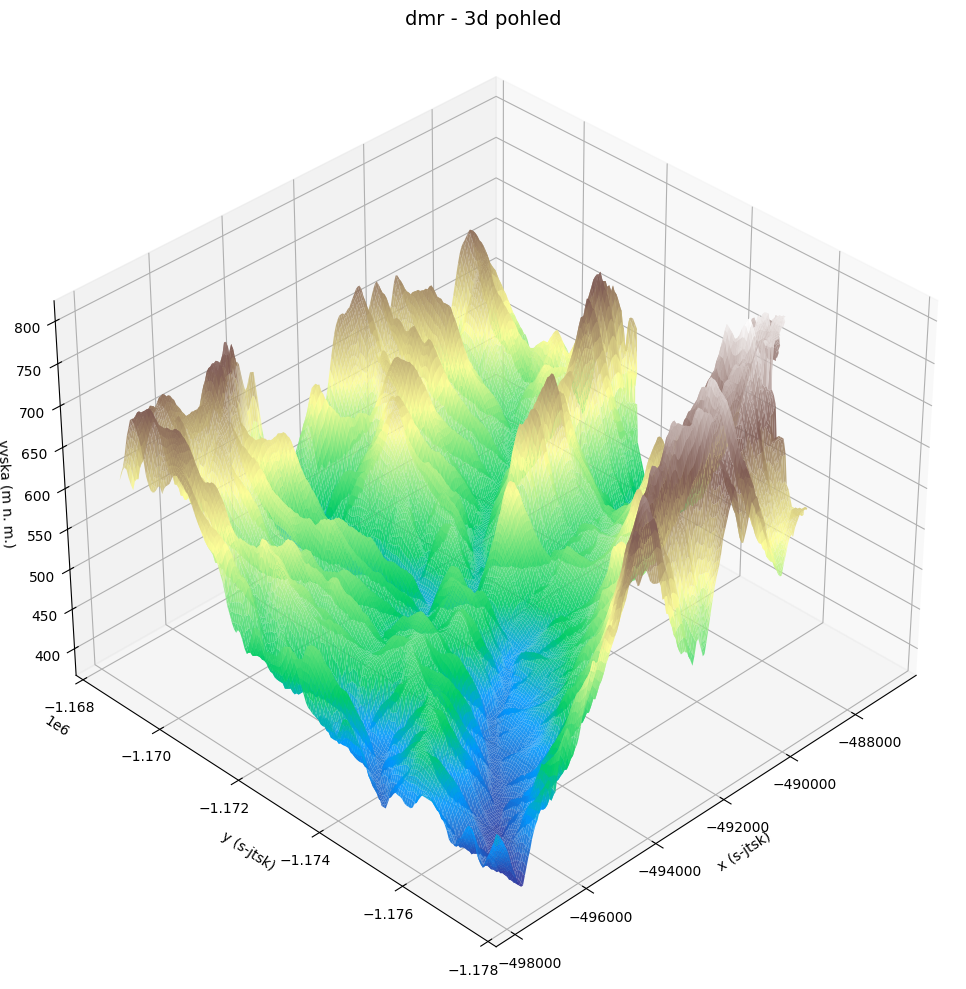

In [7]:
# 3d povrch - subsample pro vykon
STEP = max(1, min(dem.shape) // 200)
Z = dem[::STEP, ::STEP]
X = grid_xx[::STEP, ::STEP]
Y = grid_yy[::STEP, ::STEP]

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="terrain", linewidth=0, antialiased=True,
                rstride=1, cstride=1, alpha=0.9)
ax.set_xlabel("x (s-jtsk)")
ax.set_ylabel("y (s-jtsk)")
ax.set_zlabel("vyska (m n. m.)")
ax.set_title("dmr - 3d pohled", fontsize=14)
ax.view_init(elev=35, azim=225)
plt.tight_layout()
plt.show()

## 7. Export

In [ ]:
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ulozeni dmr jako numpy array
np.savez_compressed(OUT_DIR / "dmr_grid.npz",
                    dem=dem, grid_x=grid_x, grid_y=grid_y,
                    resolution=RESOLUTION, bbox_sjtsk=bbox_sjtsk)

# ulozeni vizualizaci
fig1, ax1 = plt.subplots(figsize=(14, 8))
im1 = ax1.imshow(dem, origin="lower", extent=extent, cmap="terrain")
plt.colorbar(im1, ax=ax1, shrink=0.7, label="m n. m.")
ax1.set_title("dmr"); ax1.set_aspect("equal")
fig1.savefig(OUT_DIR / "dmr_elevation.png", dpi=150, bbox_inches="tight")
plt.close(fig1)

fig2, ax2 = plt.subplots(figsize=(14, 8))
rgb = ls.shade(dem, cmap=plt.cm.terrain, vert_exag=2, blend_mode="overlay",
               dx=RESOLUTION, dy=RESOLUTION)
ax2.imshow(rgb, origin="lower", extent=extent)
ax2.set_title("dmr - hillshade"); ax2.set_aspect("equal")
fig2.savefig(OUT_DIR / "dmr_hillshade.png", dpi=150, bbox_inches="tight")
plt.close(fig2)

print("ulozeno:")
for f in ["dmr_grid.npz", "dmr_elevation.png", "dmr_hillshade.png"]:
    p = OUT_DIR / f
    print(f"  {p} ({p.stat().st_size / 1024:.0f} kb)")

UloÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾eno:
  data\processed\dmr_grid.npz (2158 KB)
  data\processed\dmr_elevation.png (628 KB)
  data\processed\dmr_hillshade.png (23 KB)


  X [-483000, -482000]: 12 bodÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¯


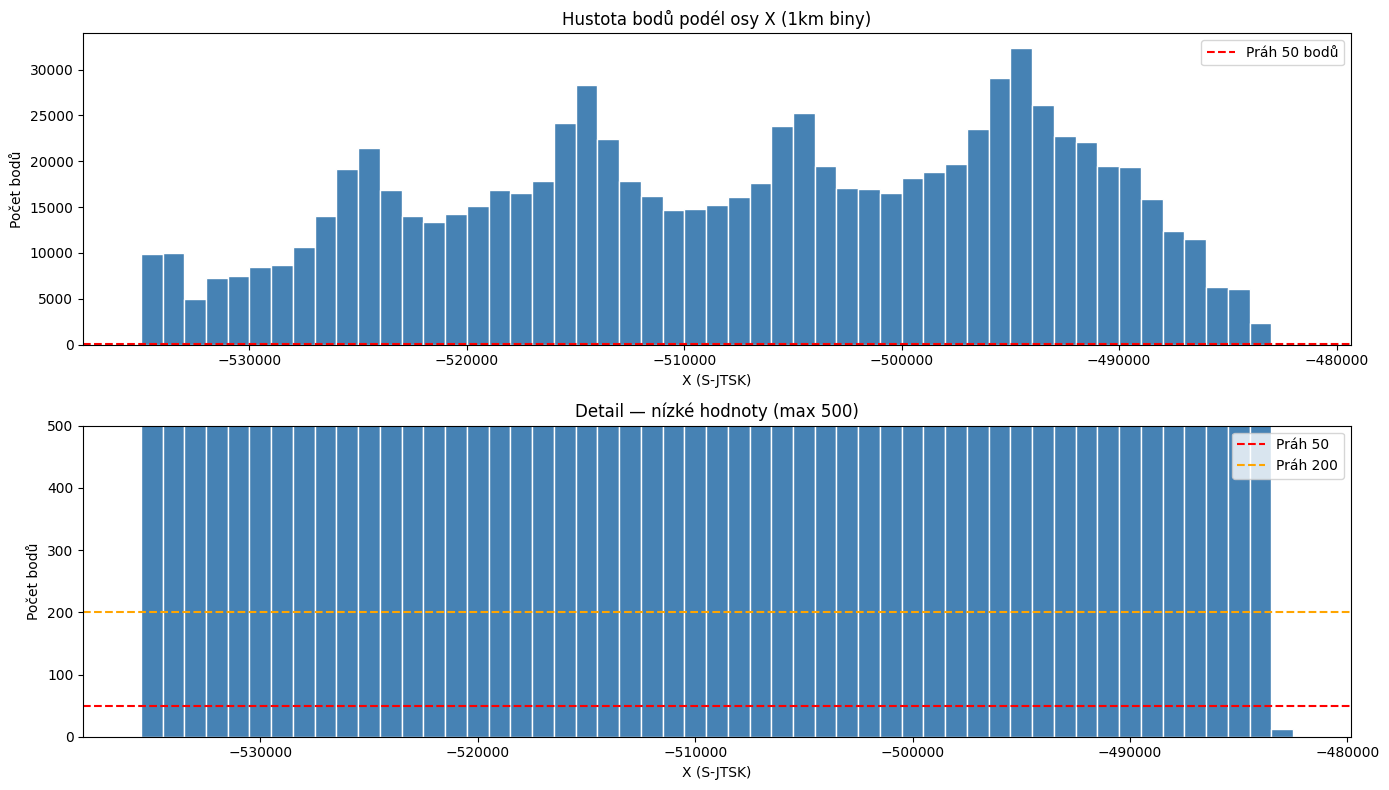

In [ ]:
# diagnostika: histogram bodu podel osy x
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# histogram s 1 km biny
bins_1km = np.arange(pts_x.min(), pts_x.max() + 1000, 1000)
counts, edges, _ = ax1.hist(pts_x, bins=bins_1km, color="steelblue", edgecolor="white")
ax1.set_title("hustota bodu podel osy x (1 km biny)")
ax1.set_xlabel("x (s-jtsk)")
ax1.set_ylabel("pocet bodu")
ax1.axhline(y=50, color="red", linestyle="--", label="prah 50 bodu")
ax1.legend()

# detailni pohled na nizke hodnoty
ax2.bar(edges[:-1], counts, width=1000, color="steelblue", edgecolor="white")
ax2.set_ylim(0, 500)
ax2.set_title("detail - nizke hodnoty (max 500)")
ax2.set_xlabel("x (s-jtsk)")
ax2.set_ylabel("pocet bodu")
ax2.axhline(y=50, color="red", linestyle="--", label="prah 50")
ax2.axhline(y=200, color="orange", linestyle="--", label="prah 200")
ax2.legend()

# vypis binu s malo body
for i, (c, e) in enumerate(zip(counts, edges[:-1])):
    if c < 500:
        print(f"  x [{e:.0f}, {e+1000:.0f}]: {c:.0f} bodu")

plt.tight_layout()
plt.show()